# Revenue Risk Analysis

## Problem Statement
The business is generating revenue but is experiencing instability in growth. There is a need to identify where revenue is being lost across the customer journey, operations, and seller performance.

## Objective

The objective of this project is to identify and quantify **revenue risk** in an e-commerce business by analyzing customer behavior, delivery experience, and operational performance.

The analysis focuses on:
- customer retention and repeat purchasing behavior
- experience-driven revenue loss due to delivery delays
- operational leakage from cancellations and seller performance

The goal is to estimate revenue loss, identify major leakage sources, and highlight priority areas for business action.

## Dataset Overview

This analysis uses the Olist e-commerce dataset, which includes customer orders, payments, delivery timelines, reviews, sellers, and products.

## Analysis Structure

The revenue leakage analysis is conducted in three stages:
1. Customer Behavior Analysis
2. Experience-Driven Analysis
3. Operational Analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

import warnings
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect('olist.db')

## Data Overview
Following step are performed:

1. Database Inspection
2. Missing Value Analysis
3. Duplicate Record Validation
4. Referential Integrity Checks
5. Value and Range Validation
6. Revenue Consistency Validation

In [3]:
tables = pd.read_sql('''SELECT name FROM sqlite_master WHERE type = "table"''', conn)
tables

,name
0,customers
1,location
2,order_items
3,payments
4,reviews
5,orders
6,product
7,seller
8,product_category


In [4]:
# Checking row_count for each table (to confirm if all csv(s) loaded correctly)
for t in tables['name']:
    print(f"\nTable: {t}\n")
    display(pd.read_sql(f'''SELECT COUNT(*) FROM {t} LIMIT 5;''', conn))


Table: customers



,COUNT(*)
0,99441



Table: location



,COUNT(*)
0,1000163



Table: order_items



...

,COUNT(*)
0,32951



Table: seller



,COUNT(*)
0,3095



Table: product_category



,COUNT(*)
0,71


In [5]:
# column names for each table
for t in tables['name']:
    print(f"\nTable: {t}\n")
    cols = pd.read_sql(f'''SELECT * FROM {t} LIMIT 0;''', conn)
    print(cols.columns)
    print("-"* 50)


Table: customers

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')
--------------------------------------------------

Table: location

Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='str')
--------------------------------------------------

Table: order_items

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')
--------------------------------------------------

Table: payments

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')
--------------------------------------------------

Table: reviews

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'

In [6]:
# preview data from each table (5 rows each)
for t in tables['name']:
    print(f"\nTable : {t}")
    display(pd.read_sql(f'''SELECT * FROM {t} LIMIT 5;''', conn))
    print("-"*50)


Table : customers


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


--------------------------------------------------

Table : location


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


--------------------------------------------------

Table : order_items


...

--------------------------------------------------

Table : seller


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


--------------------------------------------------

Table : product_category


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


--------------------------------------------------


In [7]:
#checking for missing values
for table in tables['name']:
    
    # get column names
    cols = pd.read_sql(f"PRAGMA table_info({table})", conn)["name"].tolist()
    
    # build missing value query
    query = "SELECT " + ", ".join(
        [f"SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) AS {col}" for col in cols]
    ) + f" FROM {table}"
    
    result = pd.read_sql(query, conn)
    
    print(f"\nMissing values in {table}")
    display(result.transpose())


Missing values in customers


,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0



Missing values in location


,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0



Missing values in order_items


...

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2



Missing values in seller


,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0



Missing values in product_category


,0
product_category_name,0
product_category_name_english,0


There are missing values in `orders` and `reveiws` and `product` table BUT we will handle them while analysis. We will not handle them through generic approaches.

In [8]:
# Duplicate Checking

duplicate_checks = {
    "customers": ["customer_id"],
    "orders": ["order_id"],
    "seller": ["seller_id"],
    "product": ["product_id"]
} # checking for main files only as they derive others

for table, cols in duplicate_checks.items():
    
    col_string = ", ".join(cols)
    
    query = f"""
    SELECT {col_string}, COUNT(*) as count
    FROM {table}
    GROUP BY {col_string}
    HAVING COUNT(*) > 1
    """
    
    result = pd.read_sql(query, conn)
    
    print(f"\nDuplicates in {table}")
    display(result)


Duplicates in customers


,customer_id,count



Duplicates in orders


,order_id,count



Duplicates in seller


,seller_id,count



Duplicates in product


,product_id,count


No duplicates found! Means they maintain unique records. </br>
(*Used "customer_id" instead of "customer_unique_id" because unique customers shares multiple id at order level*)

**Referential Integrity Checking** </br>
*Checking mismached columns as they can distort revenue calculations*

In [9]:
# Payments without Orders
pd.read_sql("""SELECT COUNT(*) AS orphan_payments 
                FROM payments p
                LEFT JOIN orders o
                ON p.order_id = o.order_id
                WHERE o.order_id IS NULL
""", conn)

,orphan_payments
0,0


In [10]:
# Orders without Customers
pd.read_sql(""" SELECT COUNT(*) AS orphan_orders
                FROM orders o
                LEFT JOIN customers c
                ON o.customer_id = c.customer_id
                WHERE c.customer_id IS NULL
""", conn)

,orphan_orders
0,0


In [11]:
# Order Items without Orders
pd.read_sql(""" SELECT COUNT(*) AS orphan_order_items
                FROM order_items oi
                LEFT JOIN orders o
                ON oi.order_id = o.order_id
                WHERE o.order_id IS NULL
""", conn)

,orphan_order_items
0,0


In [12]:
# Order Items without Products
pd.read_sql(""" SELECT COUNT(*) AS orphan_products
                FROM order_items oi
                LEFT JOIN product p
                ON oi.product_id = p.product_id
                WHERE p.product_id IS NULL
""", conn)

,orphan_products
0,0


In [13]:
# Order Items without Sellers
pd.read_sql(""" SELECT COUNT(*) AS orphan_sellers
                FROM order_items oi
                LEFT JOIN seller s
                ON oi.seller_id = s.seller_id
                WHERE s.seller_id IS NULL
""", conn)

,orphan_sellers
0,0


In [14]:
# Payment Validaty Checking
pd.read_sql(""" SELECT COUNT(*) AS negative_payments
                FROM payments
                WHERE payment_value < 0
""", conn)

,negative_payments
0,0


In [15]:
pd.read_sql(""" SELECT COUNT(*) AS zero_payments
                FROM payments
                WHERE payment_value = 0
""", conn)

,zero_payments
0,9


In [16]:
pd.read_sql(""" SELECT payment_type, COUNT(*) AS count
                FROM payments
                WHERE payment_value = 0
                GROUP BY payment_type
""", conn)

,payment_type,count
0,not_defined,3
1,voucher,6


A small number of payment (9) have zero payment values, primarily associated with voucher based transactions or undefined payment type. Given very low frequency, these records are unlikely to affect revenue analysis.

In [17]:
# Checking Negetive Product Prices
pd.read_sql(""" SELECT COUNT(*) AS negative_prices
                FROM order_items
                WHERE price < 0
""", conn)

,negative_prices
0,0


In [18]:
# Checking Freight Anomalies
pd.read_sql(""" SELECT MIN(freight_value) AS min_freight,
                MAX(freight_value) AS max_freight
                FROM order_items
""", conn)

,min_freight,max_freight
0,0.0,409.68


In [19]:
# Order Status Distribution
pd.read_sql(""" SELECT order_status, COUNT(*) AS order_count
                FROM orders
                GROUP BY order_status
""", conn)

,order_status,order_count
0,approved,2
1,canceled,625
2,created,5
3,delivered,96478
4,invoiced,314
5,processing,301
6,shipped,1107
7,unavailable,609


Cancelled orders are one of the biggest revenue leakage sources.

In [20]:
# Valid Payment Methods
pd.read_sql(""" SELECT payment_type, COUNT(*) AS transactions
                FROM payments
                GROUP BY payment_type
""", conn)

,payment_type,transactions
0,boleto,19784
1,credit_card,76795
2,debit_card,1529
3,not_defined,3
4,voucher,5775


In [21]:
# Checking Revenue Consistency between Order value & payment value

pd.read_sql("""
WITH order_totals AS (
    SELECT order_id, SUM(price + freight_value) AS order_value
    FROM order_items
    GROUP BY order_id
),

payment_totals AS (
    SELECT order_id, SUM(payment_value) AS payment_value
    FROM payments
    GROUP BY order_id
)

SELECT o.order_id, ot.order_value, pt.payment_value
FROM orders o LEFT JOIN order_totals ot
ON o.order_id = ot.order_id
LEFT JOIN payment_totals pt
ON o.order_id = pt.order_id
WHERE ROUND(ot.order_value, 2) != ROUND(pt.payment_value, 2)
LIMIT 20
""", conn)

,order_id,order_value,payment_value
0,f04bfdbef5359607d39e66fccc9cc0de,998.50,998.49
1,8adafb3466daa5395694d3a906ff9d40,218.02,218.00
2,d5211af24819d319c02a285e7bb51750,186.75,186.76
3,bb2e64c3040ceb9b7ca2bfc602adca08,257.36,257.34
4,84d6d9710c8af32b5e88f2d1c14ab871,57.68,61.70
5,74016effecaa79d592487f6a4ee47d4b,51.51,56.96
6,239f380355f65dcb68551f07d16fc4a8,222.63,251.63
7,4c57f545143e8865ca2347d8cba154a7,139.61,151.01
8,6e57e23ecac1ae881286657694444267,350.41,333.91
9,b38b3526b8b8fdc807e8a0a42ab78573,30.06,30.19


In [22]:
pd.read_sql("""
SELECT *
FROM payments
WHERE order_id = '84d6d9710c8af32b5e88f2d1c14ab871'
""", conn)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,84d6d9710c8af32b5e88f2d1c14ab871,1,credit_card,5,61.7


In [23]:
pd.read_sql("""
SELECT *
FROM order_items
WHERE order_id = '84d6d9710c8af32b5e88f2d1c14ab871'
""", conn)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,84d6d9710c8af32b5e88f2d1c14ab871,1,61e2cc02b96d5d61c27e21754260dccd,b2ba3715d723d245138f291a6fe42594,2018-01-31 22:35:25,49.9,7.78


A small subset of orders show differences between aggregated order value (price + freight_value) and recorded payments. These differences are likely caused by installment based payments, voucher combinations, or payment processing adjustments rather than direct data inconsistencies.

## Analysis

### 1. Customer Behavior
This section evaluates whether revenue growth is supported by repeat purchasing behavior or relies primarily on acquiring new customers.

#### 1.1 One-time vs Repeat Customers
How dependent is the business on repeat customers?

In [24]:
pd.read_sql(''' SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
                FROM orders o JOIN customers c
                ON o.customer_id = c.customer_id
                WHERE o.order_status = "delivered"
                GROUP BY 1
                ORDER BY 2 DESC;
                ''', conn)

,customer_unique_id,order_count
0,8d50f5eadf50201ccdcedfb9e2ac8455,15
1,3e43e6105506432c953e165fb2acf44c,9
2,ca77025e7201e3b30c44b472ff346268,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,1b6c7548a2a1f9037c1fd3ddfed95f33,7
...,...,...
93353,0004aac84e0df4da2b147fca70cf8255,1
93354,0000f6ccb0745a6a4b88665a16c9f078,1
93355,0000f46a3911fa3c0805444483337064,1
93356,0000b849f77a49e4a4ce2b2a4ca5be3f,1


In [25]:
# Customer Classification into One-time and Repeat
query = '''
WITH customer_orders AS (
    SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY 1
)
SELECT CASE WHEN order_count = 1 THEN 'One-time' 
            ELSE 'Repeat' END AS customer_type,
       COUNT(*) AS customer_count
FROM customer_orders
GROUP BY customer_type;'''

order_freq = pd.read_sql(query, conn)
order_freq

,customer_type,customer_count
0,One-time,90557
1,Repeat,2801


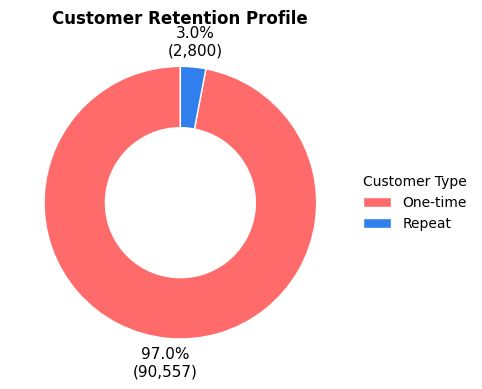

In [26]:
plt.figure(figsize=(6,4))

colors = ['#FF6B6B', '#2F80ED']  # One-Time, Repeat

plt.pie(
    order_freq['customer_count'],
    colors=colors,
    startangle=90,
    autopct=lambda p: f'{p:.1f}%\n({int(p*order_freq.customer_count.sum()/100):,})',
    pctdistance=1.18,   # Moves labels outside donut
    wedgeprops={'width':0.45, 'edgecolor':'white'},
    textprops={'fontsize':11}
)

plt.title(
    "Customer Retention Profile",
    fontweight='bold'
)

plt.legend(
    order_freq['customer_type'],
    title="Customer Type",
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

#### 1.2 Time-to-Second-Purchase Analysis
For customers who do return, how long does it take them to place their second order?

In [27]:
query = '''
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_purchase_timestamp,
        ROW_NUMBER() OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY o.order_purchase_timestamp
        ) AS order_rank
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
),

first_second_orders AS (
    SELECT
        customer_unique_id,
        MAX(CASE WHEN order_rank = 1
            THEN order_purchase_timestamp END) AS first_order,
        MAX(CASE WHEN order_rank = 2
            THEN order_purchase_timestamp END) AS second_order
    FROM customer_orders
    GROUP BY customer_unique_id
    HAVING second_order IS NOT NULL
)

SELECT
    customer_unique_id,
    ROUND(
        JULIANDAY(second_order) - JULIANDAY(first_order),
        0
    ) AS days_to_second_purchase
FROM first_second_orders;
'''

repeat_gap = pd.read_sql(query, conn)
repeat_gap.head()

,customer_unique_id,days_to_second_purchase
0,004288347e5e88a27ded2bb23747066c,171.0
1,00a39521eb40f7012db50455bf083460,11.0
2,00cc12a6d8b578b8ebd21ea4e2ae8b27,0.0
3,011575986092c30523ecb71ff10cb473,60.0
4,011b4adcd54683b480c4d841250a987f,177.0


In [28]:
print("Average days to second purchase:", round(repeat_gap['days_to_second_purchase'].mean(), 1))

print("Median days to second purchase:", round(repeat_gap['days_to_second_purchase'].median(), 1))

Average days to second purchase: 81.2
Median days to second purchase: 29.0


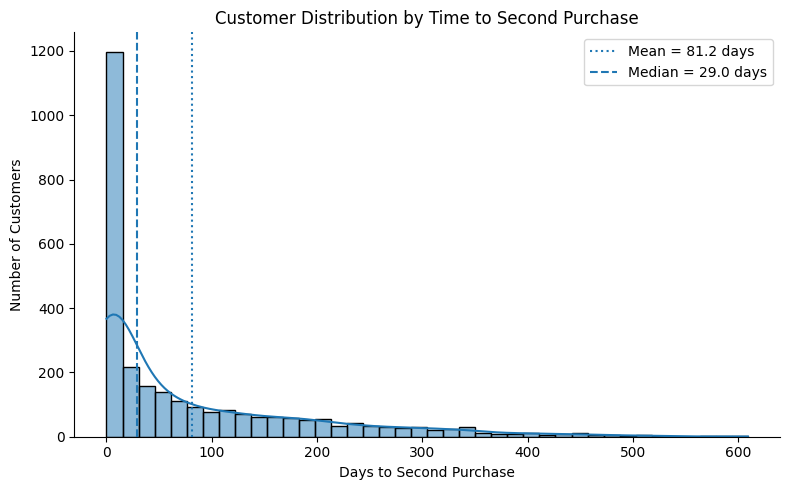

In [29]:
mean_gap = repeat_gap['days_to_second_purchase'].mean()
median_gap = repeat_gap['days_to_second_purchase'].median()

plt.figure(figsize=(8,5))

sns.histplot(
    repeat_gap['days_to_second_purchase'],
    bins=40,
    kde=True
)

plt.axvline(
    mean_gap,
    linestyle=':',
    label=f'Mean = {mean_gap:.1f} days'
)

plt.axvline(
    median_gap,
    linestyle='--',
    label=f'Median = {median_gap:.1f} days'
)

plt.xlabel("Days to Second Purchase")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by Time to Second Purchase")

sns.despine()

plt.legend()
plt.tight_layout()
plt.show()

In [30]:
bins = [0, 30, 60, 90, 180, 365, 1000]
labels = [
    '0-30',
    '31-60',
    '61-90',
    '91-180',
    '181-365',
    '365+'
]

repeat_gap['purchase_gap_bucket'] = pd.cut(
    repeat_gap['days_to_second_purchase'],
    bins=bins,
    labels=labels
)

bucket_dist = (
    repeat_gap['purchase_gap_bucket']
    .value_counts()
    .sort_index()
)

bucket_perc = (
    bucket_dist / bucket_dist.sum() * 100
).round(2)

bucket_summary = pd.DataFrame({
    'customer_count': bucket_dist,
    'percentage': bucket_perc
})

bucket_summary['cumulative_%'] = bucket_summary['percentage'].cumsum().round(2)

bucket_summary

,customer_count,percentage,cumulative_%
purchase_gap_bucket,,,
0-30,583,29.61,29.61
31-60,297,15.08,44.69
61-90,196,9.95,54.64
91-180,412,20.92,75.56
181-365,399,20.26,95.82
365+,82,4.16,99.98


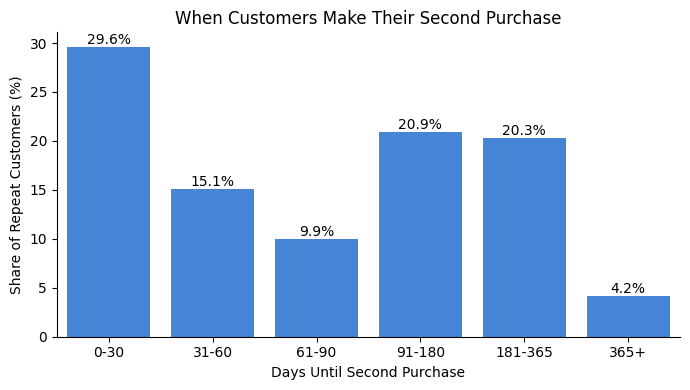

In [31]:
plt.figure(figsize=(7,4))

ax = sns.barplot(
    x=bucket_summary.index,
    y='percentage',
    data=bucket_summary.reset_index(),
    color='#2F80ED'
)

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.xlabel("Days Until Second Purchase")
plt.ylabel("Share of Repeat Customers (%)")
plt.title("When Customers Make Their Second Purchase")

sns.despine()
plt.tight_layout()
plt.show()

**Insight**

- Repeat purchases occur relatively quickly, with nearly 30% of customers returning within 30 days of their first order.

- More importantly, over 54% of repeat customers make their second purchase within 90 days, indicating that the first three months are the most critical period for customer retention and engagement.

#### 1.3 Cohort Retention Analysis

Are newer customers retaining better or worse over time?

In [32]:
query = '''
SELECT 
    c.customer_unique_id,
    DATE(o.order_purchase_timestamp) AS order_date
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
ORDER BY c.customer_unique_id, order_date;
'''

customer_orders = pd.read_sql(query, conn)
customer_orders.head()

,customer_unique_id,order_date
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07
2,0000f46a3911fa3c0805444483337064,2017-03-10
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14


In [33]:
query = '''
SELECT
    c.customer_unique_id,
    MIN(DATE(o.order_purchase_timestamp)) AS first_order_date,
    STRFTIME('%Y-%m', MIN(DATE(o.order_purchase_timestamp))) AS acquisition_cohort
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id;
'''

customer_cohort = pd.read_sql(query, conn)
customer_cohort.head()

,customer_unique_id,first_order_date,acquisition_cohort
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03-10,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14,2017-11


In [34]:
cohort_orders = customer_orders.merge(customer_cohort, on='customer_unique_id')

cohort_orders['order_date'] = pd.to_datetime(cohort_orders['order_date'])

cohort_orders['first_order_date'] = pd.to_datetime(
    cohort_orders['first_order_date'])

cohort_orders['days_since_first_order'] = (
    cohort_orders['order_date'] - cohort_orders['first_order_date']).dt.days

cohort_orders.head()

,customer_unique_id,order_date,first_order_date,acquisition_cohort,days_since_first_order
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,2018-05-10,2018-05,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,2018-05-07,2018-05,0
2,0000f46a3911fa3c0805444483337064,2017-03-10,2017-03-10,2017-03,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12,2017-10-12,2017-10,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14,2017-11-14,2017-11,0


In [35]:
# Create retention flags for each order

cohort_orders['retained_30'] = cohort_orders['days_since_first_order'].between(1, 30)
cohort_orders['retained_60'] = cohort_orders['days_since_first_order'].between(1, 60)
cohort_orders['retained_90'] = cohort_orders['days_since_first_order'].between(1, 90)

# Convert order-level flags to customer-level retention

retention_flags = (
    cohort_orders
    .groupby(['customer_unique_id', 'acquisition_cohort'])
        [['retained_30', 'retained_60', 'retained_90']].max().reset_index()
)

retention_flags.head()

,customer_unique_id,acquisition_cohort,retained_30,retained_60,retained_90
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05,False,False,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05,False,False,False
2,0000f46a3911fa3c0805444483337064,2017-03,False,False,False
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10,False,False,False
4,0004aac84e0df4da2b147fca70cf8255,2017-11,False,False,False


In [36]:
#What % of customers in each cohort returned?

cohort_retention = (
    retention_flags
    .groupby('acquisition_cohort')
    .agg(
        customer_count=('customer_unique_id', 'count'),
        retention_30=('retained_30', 'mean'),
        retention_60=('retained_60', 'mean'),
        retention_90=('retained_90', 'mean')
    )
    .reset_index()
)

cohort_retention[
    ['retention_30',
     'retention_60',
     'retention_90']
] *= 100

cohort_retention = cohort_retention.round(2)

cohort_retention

,acquisition_cohort,customer_count,retention_30,retention_60,retention_90
0,2016-09,1,0.00,0.00,0.00
1,2016-10,262,0.38,0.38,0.38
2,2016-12,1,100.00,100.00,100.00
3,2017-01,717,0.56,0.84,0.84
4,2017-02,1628,0.61,0.74,0.92
5,2017-03,2503,0.48,0.76,1.28
6,2017-04,2256,0.71,1.06,1.33
7,2017-05,3451,0.90,1.25,1.59
8,2017-06,3037,0.56,0.99,1.42
9,2017-07,3752,0.77,1.12,1.31


In [37]:
plot_data = cohort_retention[cohort_retention['customer_count'] >= 100]

plot_data

,acquisition_cohort,customer_count,retention_30,retention_60,retention_90
1,2016-10,262,0.38,0.38,0.38
3,2017-01,717,0.56,0.84,0.84
4,2017-02,1628,0.61,0.74,0.92
5,2017-03,2503,0.48,0.76,1.28
6,2017-04,2256,0.71,1.06,1.33
7,2017-05,3451,0.90,1.25,1.59
8,2017-06,3037,0.56,0.99,1.42
9,2017-07,3752,0.77,1.12,1.31
10,2017-08,4057,0.62,1.23,1.43
11,2017-09,4004,0.92,1.37,1.82


In [38]:
cohort_retention[['retention_30',
                  'retention_60',
                  'retention_90']].describe()

,retention_30,retention_60,retention_90
count,23.000000,23.000000,23.000000
mean,4.923478,5.210870,5.406522
std,20.726922,20.665817,20.624856
min,0.000000,0.000000,0.000000
25%,0.535000,0.800000,0.930000
50%,0.610000,0.930000,1.270000
75%,0.765000,1.170000,1.365000
max,100.000000,100.000000,100.000000


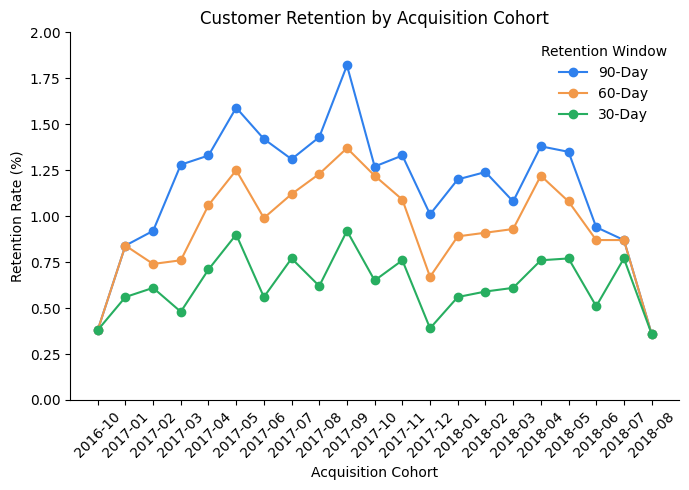

In [39]:
plt.figure(figsize=(7,5))

plt.plot(
    plot_data['acquisition_cohort'],
    plot_data['retention_90'],
    marker='o',
    color='#2F80ED',
    label='90-Day'
)

plt.plot(
    plot_data['acquisition_cohort'],
    plot_data['retention_60'],
    marker='o',
    color='#F2994A',
    label='60-Day'
)

plt.plot(
    plot_data['acquisition_cohort'],
    plot_data['retention_30'],
    marker='o',
    color='#27AE60',
    label='30-Day'
)

plt.ylim(0, 2)

plt.xticks(rotation=45)

plt.xlabel("Acquisition Cohort")
plt.ylabel("Retention Rate (%)")

plt.title("Customer Retention by Acquisition Cohort")

plt.legend(
    frameon=False,
    title="Retention Window"
)

sns.despine()
plt.tight_layout()
plt.show()

#### 1.4 Revenue by Customer-Type

In [40]:
query = '''
WITH customer_orders AS (
    SELECT c.customer_unique_id, COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id 
    ),

customer_revenue AS (
    SELECT c.customer_unique_id, SUM(p.payment_value) AS revenue
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    JOIN payments p 
    ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
    )
    
SELECT CASE WHEN co.order_count = 1 THEN 'One-time'
            ELSE 'Repeat' END AS customer_type,
       SUM(cr.revenue) AS total_revenue
FROM customer_orders co JOIN customer_revenue cr
ON co.customer_unique_id = cr.customer_unique_id
GROUP BY customer_type;
'''
revenue_per_type = pd.read_sql(query, conn)
revenue_per_type

,customer_type,total_revenue
0,One-time,14558104.56
1,Repeat,864357.21


In [41]:
revenue_per_type['revenue_perc'] = ((revenue_per_type['total_revenue'] / revenue_per_type['total_revenue'].sum())* 100).round(2)
revenue_per_type['revenue_perc']

0    94.4
1     5.6
Name: revenue_perc, dtype: float64

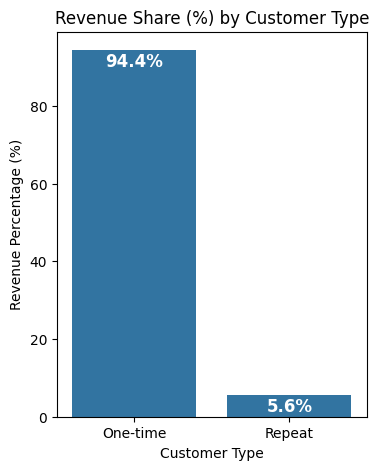

In [42]:
plt.figure(figsize = (4,5))
ax = sns.barplot(data = revenue_per_type, x = 'customer_type', y = 'revenue_perc')
ax.bar_label(ax.containers[0], color='w', fontsize=12, fontweight='bold', padding = -15, fmt='%.1f%%')
plt.xlabel("Customer Type")
plt.ylabel("Revenue Percentage (%)")
plt.title("Revenue Share (%) by Customer Type")
plt.show()

In [43]:
# Average Revenue per Customer (ARPC)
query = '''
WITH customer_orders AS (
    SELECT  c.customer_unique_id, 
            COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

customer_revenue AS (
    SELECT  c.customer_unique_id, 
            SUM(p.payment_value) AS revenue
    FROM orders o JOIN customers c
    ON o.customer_id = c.customer_id
    JOIN payments p 
    ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
    )

SELECT CASE WHEN co.order_count = 1 THEN 'One-time' 
            ELSE 'Repeat' END AS customer_type,
       COUNT(*) AS customer_count,
       SUM(cr.revenue) AS total_revenue
FROM customer_orders co JOIN customer_revenue cr
ON co.customer_unique_id = cr.customer_unique_id
GROUP BY customer_type;
'''

revenue_customer = pd.read_sql(query, conn)
revenue_customer

,customer_type,customer_count,total_revenue
0,One-time,90556,14558104.56
1,Repeat,2801,864357.21


In [44]:
revenue_customer['avg_revenue'] = (revenue_customer['total_revenue'] / revenue_customer['customer_count']).round(2)
revenue_customer

,customer_type,customer_count,total_revenue,avg_revenue
0,One-time,90556,14558104.56,160.76
1,Repeat,2801,864357.21,308.59


In [45]:
print("Ratio of average revenue per customer:",
      (revenue_customer['avg_revenue'].iloc[1] / revenue_customer['avg_revenue'].iloc[0]).round(2))

Ratio of average revenue per customer: 1.92


#### 1.5 Revenue Opportunity Modeling

If repeat conversion improves, how much revenue can the business unlock?

In [46]:
revenue_customer.head()

,customer_type,customer_count,total_revenue,avg_revenue
0,One-time,90556,14558104.56,160.76
1,Repeat,2801,864357.21,308.59


In [47]:
total_customers = revenue_customer['customer_count'].sum()

current_repeat_customers = (revenue_customer.loc[revenue_customer['customer_type'] == 'Repeat', 'customer_count'].iloc[0])

avg_repeat_revenue = (revenue_customer.loc[revenue_customer['customer_type'] == 'Repeat', 'avg_revenue'].iloc[0])

print(total_customers)
print(current_repeat_customers)
print(avg_repeat_revenue)

93357
2801
308.59


In [48]:
target_rates = [4, 5, 6, 7, 8, 9, 10]

opportunity = []

for rate in target_rates:
    
    target_repeat_customers = (
        total_customers * rate / 100
    )
    
    additional_customers = (
        target_repeat_customers
        - current_repeat_customers
    )
    
    additional_revenue = (
        additional_customers
        * avg_repeat_revenue
    )
    
    opportunity.append([
        rate,
        round(additional_customers),
        round(additional_revenue, 2)
    ])

opportunity_df = pd.DataFrame(
    opportunity,
    columns=[
        'target_repeat_rate',
        'additional_repeat_customers',
        'potential_additional_revenue'
    ]
)

opportunity_df

,target_repeat_rate,additional_repeat_customers,potential_additional_revenue
0,4,933,288000.88
1,5,1867,576091.24
2,6,2800,864181.61
3,7,3734,1152271.97
4,8,4668,1440362.34
5,9,5601,1728452.71
6,10,6535,2016543.07


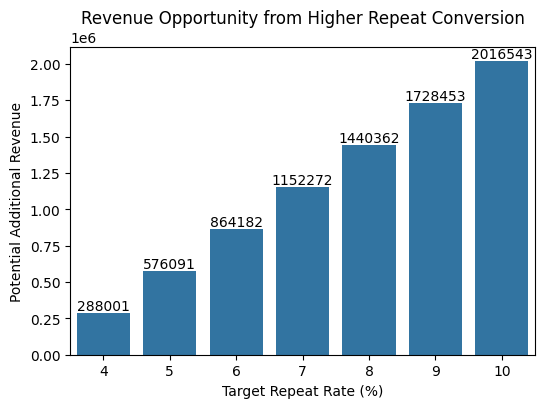

In [49]:
plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=opportunity_df,
    x='target_repeat_rate',
    y='potential_additional_revenue'
)

ax.bar_label(
    ax.containers[0],
    fmt='%.0f'
)

plt.xlabel("Target Repeat Rate (%)")
plt.ylabel("Potential Additional Revenue")
plt.title("Revenue Opportunity from Higher Repeat Conversion")

plt.show()

#### 1.6 Customer Lifetime Value Distribution (median / spread)

Are repeat customers broadly more valuable, or is average revenue skewed by a few big spenders?

In [50]:
query = '''
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o
    JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),

customer_revenue AS (
    SELECT
        c.customer_unique_id,
        SUM(p.payment_value) AS revenue
    FROM orders o
    JOIN customers c
    ON o.customer_id = c.customer_id
    JOIN payments p
    ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    cr.customer_unique_id,

    CASE
        WHEN co.order_count = 1 THEN 'One-time'
        ELSE 'Repeat'
    END AS customer_type,

    cr.revenue

FROM customer_revenue cr
JOIN customer_orders co
ON cr.customer_unique_id = co.customer_unique_id;
'''

customer_value = pd.read_sql(query, conn)
customer_value.head()

,customer_unique_id,customer_type,revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,One-time,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,One-time,27.19
2,0000f46a3911fa3c0805444483337064,One-time,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,One-time,43.62
4,0004aac84e0df4da2b147fca70cf8255,One-time,196.89


In [51]:
customer_value.groupby('customer_type')['revenue'].agg(
    ['mean', 'median']
).round(2)

,mean,median
customer_type,,
One-time,160.76,105.39
Repeat,308.59,225.55


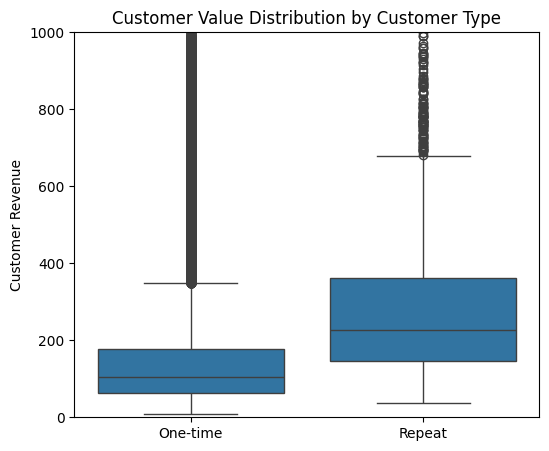

In [52]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=customer_value,
    x='customer_type',
    y='revenue'
)

plt.ylim(0, 1000)

plt.xlabel("")
plt.ylabel("Customer Revenue")
plt.title("Customer Value Distribution by Customer Type")

plt.show()

#### 1.7 How Far Do Customers Continue Buying?

In [53]:
query = '''
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    order_count,
    COUNT(*) AS customer_count
FROM customer_orders
WHERE order_count > 1
GROUP BY order_count
ORDER BY order_count;
'''

repeat_order_distribution = pd.read_sql(query, conn)

repeat_order_distribution

,order_count,customer_count
0,2,2573
1,3,181
2,4,28
3,5,9
4,6,5
5,7,3
6,9,1
7,15,1


In [54]:
repeat_order_distribution['percentage'] = (
    repeat_order_distribution['customer_count']
    / repeat_order_distribution['customer_count'].sum()
    * 100
).round(2)

repeat_order_distribution

,order_count,customer_count,percentage
0,2,2573,91.86
1,3,181,6.46
2,4,28,1.00
3,5,9,0.32
4,6,5,0.18
5,7,3,0.11
6,9,1,0.04
7,15,1,0.04


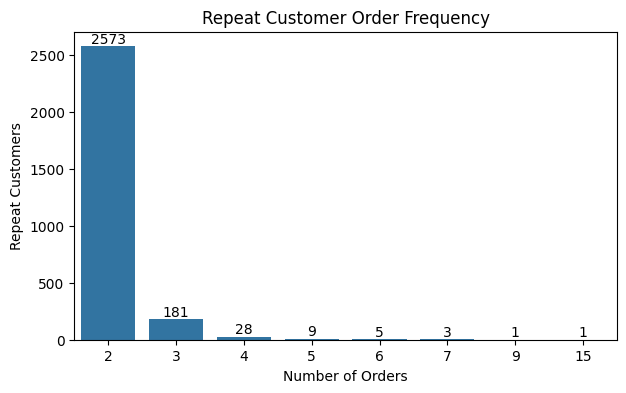

In [55]:
plt.figure(figsize=(7,4))

ax = sns.barplot(
    data=repeat_order_distribution,
    x='order_count',
    y='customer_count'
)

ax.bar_label(
    ax.containers[0]
)

plt.xlabel("Number of Orders")
plt.ylabel("Repeat Customers")
plt.title("Repeat Customer Order Frequency")

plt.show()

In [56]:
query = '''
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS order_count
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_unique_id
)

SELECT
    order_count,
    COUNT(*) AS customer_count
FROM customer_orders
GROUP BY order_count
ORDER BY order_count;
'''

order_depth = pd.read_sql(query, conn)

order_depth

,order_count,customer_count
0,1,90557
1,2,2573
2,3,181
3,4,28
4,5,9
5,6,5
6,7,3
7,9,1
8,15,1


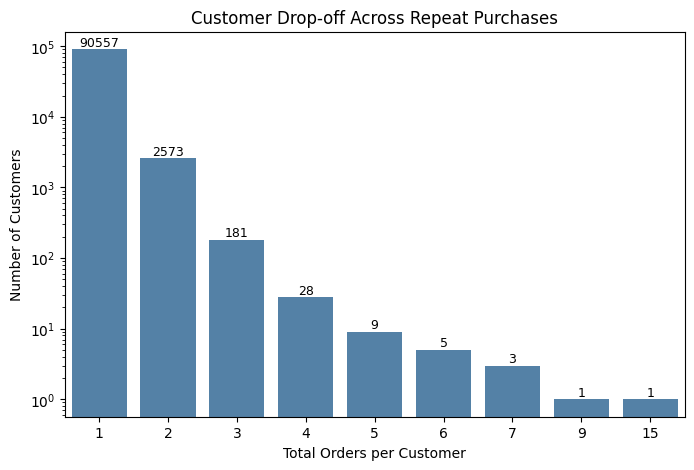

In [57]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=order_depth,
    x='order_count',
    y='customer_count',
    color='steelblue'
)

ax.bar_label(
    ax.containers[0],
    fontsize=9
)

plt.xlabel("Total Orders per Customer")
plt.ylabel("Number of Customers")
plt.title("Customer Drop-off Across Repeat Purchases")

plt.yscale('log')   # important

plt.show()

### Findings

- Repeat customers generated nearly `2x` higher revenue per customer than one-time buyers.
- Increasing the repeat purchase rate to `5%` could unlock approximately `₹0.58M` in additional revenue without acquiring new customers.
- Increasing the repeat purchase rate to `10%` could generate more than `₹2.0M` in additional revenue from the existing customer base.
- Revenue growth is heavily dependent on customer acquisition, indicating significant untapped value in improving customer retention.

### Recommendation

- Focus on increasing second-order conversion, as even modest improvements in repeat purchasing have the potential to generate substantial revenue from existing customers.

### 2. Experience-Driven Leakage
This section evaluates whether delivery performance creates revenue risk through delayed orders, customer dissatisfaction, and geographically concentrated operational issues.

In [58]:
pd.read_sql("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT order_id) AS orders
FROM order_items
""", conn)

,rows,orders
0,112650,98666


This means:

- We cannot directly join delayed orders to product categories and use payment_value.

Because one order revenue would get duplicated across multiple products.

#### 2.1 Late Delivery Identification

In [59]:
query = '''SELECT count(*) AS total_orders, 
                  SUM(CASE WHEN order_estimated_delivery_date < order_delivered_customer_date THEN 1 ELSE 0 END) AS late_delivery
           FROM orders
           WHERE order_status = "delivered";
           '''
late_orders = pd.read_sql(query, conn)
late_orders

,total_orders,late_delivery
0,96478,7826


In [60]:
late_delivery_perc = (late_orders['late_delivery'][0] / late_orders['total_orders'][0] * 100.0).round(2)

print("Percentage of total orders that were late are:", late_delivery_perc, "%")

Percentage of total orders that were late are: 8.11 %


#### 2.2 Customer Impact of Delays

In [61]:
query = '''
SELECT COUNT(DISTINCT c.customer_unique_id) AS total_customers, 
       COUNT(DISTINCT CASE WHEN o.order_estimated_delivery_date < o.order_delivered_customer_date 
       THEN c.customer_unique_id END) AS affected_customers
FROM customers c JOIN orders o
ON c.customer_id = o.customer_id
WHERE o.order_status = "delivered";
'''
# (customers experienced at least one late delivery)
affected_customers = pd.read_sql(query, conn)
affected_customers

,total_customers,affected_customers
0,93358,7771


#### 2.3 Revenue at Risk from Delays

In [62]:
query = '''
SELECT SUM(p.payment_value) AS total_revenue,
       SUM(CASE WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN p.payment_value END) AS revenue_at_risk
FROM payments p JOIN orders o
ON p.order_id = o.order_id
WHERE o.order_status = "delivered";
'''
delay_revenue = pd.read_sql(query, conn)
delay_revenue

,total_revenue,revenue_at_risk
0,15422461.77,1351646.79


In [63]:
print("Percentage of total revenue linked to late delivered orders:", 
      float((delay_revenue['revenue_at_risk'][0] / delay_revenue['total_revenue'][0] * 100).round(2)), "%"
)

Percentage of total revenue linked to late delivered orders: 8.76 %


#### 2.4 Delayed Revenue Concentration by Product Category

**Analytical Note**

Payment values are recorded at the order level, while product categories exist at the item level. 

Since a single order may contain products from multiple categories, category-level revenue is estimated using item-level order value (`price + freight_value`) rather than order-level payment values. 

This avoids introducing revenue allocation assumptions across categories.

In [64]:
# Which product categories contribute the most to delayed-delivery revenue exposure?

# Delayed delivery revenue by product category

query = '''
WITH delayed_orders AS (
    SELECT
        order_id
    FROM orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date > order_estimated_delivery_date
)

SELECT
    pc.product_category_name_english AS category,

    COUNT(DISTINCT oi.order_id) AS delayed_orders,

    ROUND(
        SUM(oi.price + oi.freight_value),
        2
    ) AS delayed_revenue

FROM delayed_orders d

JOIN order_items oi
ON d.order_id = oi.order_id

JOIN product p
ON oi.product_id = p.product_id

LEFT JOIN product_category pc
ON p.product_category_name = pc.product_category_name

GROUP BY pc.product_category_name_english

HAVING delayed_revenue > 0

ORDER BY delayed_revenue DESC;
'''

delay_category = pd.read_sql(query, conn)

delay_category.head(10)

,category,delayed_orders,delayed_revenue
0,health_beauty,775,129920.77
1,watches_gifts,468,113264.05
2,bed_bath_table,811,111133.73
3,sports_leisure,584,99326.52
4,computers_accessories,503,85693.21
5,furniture_decor,535,85079.64
6,auto,328,80438.41
7,housewares,399,57817.53
8,cool_stuff,243,56458.79
9,baby,258,48989.03


In [65]:
delay_category['revenue_share'] = (
    delay_category['delayed_revenue']
    / delay_category['delayed_revenue'].sum()
    * 100
).round(2)

delay_category.head(15)

,category,delayed_orders,delayed_revenue,revenue_share
0,health_beauty,775,129920.77,9.61
1,watches_gifts,468,113264.05,8.38
2,bed_bath_table,811,111133.73,8.22
3,sports_leisure,584,99326.52,7.35
4,computers_accessories,503,85693.21,6.34
5,furniture_decor,535,85079.64,6.29
6,auto,328,80438.41,5.95
7,housewares,399,57817.53,4.28
8,cool_stuff,243,56458.79,4.18
9,baby,258,48989.03,3.62


In [66]:
delay_category['cumulative_share'] = (
    delay_category['revenue_share']
    .cumsum()
    .round(2)
)

delay_category.head(15)

,category,delayed_orders,delayed_revenue,revenue_share,cumulative_share
0,health_beauty,775,129920.77,9.61,9.61
1,watches_gifts,468,113264.05,8.38,17.99
2,bed_bath_table,811,111133.73,8.22,26.21
3,sports_leisure,584,99326.52,7.35,33.56
4,computers_accessories,503,85693.21,6.34,39.90
5,furniture_decor,535,85079.64,6.29,46.19
6,auto,328,80438.41,5.95,52.14
7,housewares,399,57817.53,4.28,56.42
8,cool_stuff,243,56458.79,4.18,60.60
9,baby,258,48989.03,3.62,64.22


In [67]:
delay_category['category'].isna().sum()

np.int64(1)

In [68]:
delay_category['category'] = (
    delay_category['category']
    .fillna('Unknown')
)

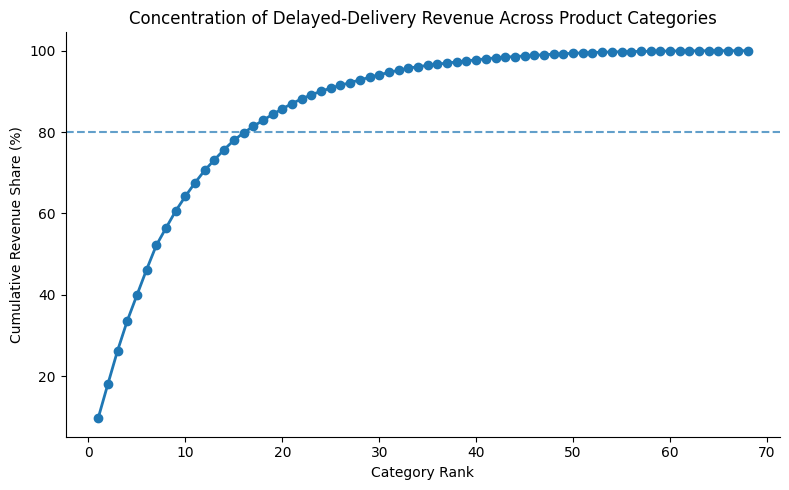

In [69]:
delay_category['category_rank'] = range(1, len(delay_category) + 1)

plt.figure(figsize=(8,5))

plt.plot(
    delay_category['category_rank'],
    delay_category['cumulative_share'],
    marker='o',
    linewidth=2
)

plt.axhline(
    y=80,
    linestyle='--',
    alpha=0.7
)

plt.xlabel("Category Rank")
plt.ylabel("Cumulative Revenue Share (%)")
plt.title("Concentration of Delayed-Delivery Revenue Across Product Categories")

sns.despine()
plt.tight_layout()
plt.show()

In [70]:
delay_category.head()

,category,delayed_orders,delayed_revenue,revenue_share,cumulative_share,category_rank
0,health_beauty,775,129920.77,9.61,9.61,1
1,watches_gifts,468,113264.05,8.38,17.99,2
2,bed_bath_table,811,111133.73,8.22,26.21,3
3,sports_leisure,584,99326.52,7.35,33.56,4
4,computers_accessories,503,85693.21,6.34,39.90,5


**Finding**

- Delayed-delivery revenue exposure is broadly distributed across the product portfolio.

- The top 5 categories account for only `39.9%` of delayed-delivery revenue, while approximately `15 categories` are required to explain `nearly 80%` of total exposure.

> This suggests that delivery-related revenue risk is not concentrated within a small set of product categories.

#### 2.5 Geographic Concentration of Delays

Are delayed deliveries concentrated within a few customer states or distributed across the customer base?

In [71]:
query = '''
WITH delayed_orders AS (
    SELECT
        o.order_id,
        c.customer_state
    FROM orders o
    JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date > o.order_estimated_delivery_date
)

SELECT
    customer_state,
    COUNT(DISTINCT order_id) AS delayed_orders

FROM delayed_orders

GROUP BY customer_state

ORDER BY delayed_orders DESC;
'''

delay_by_state = pd.read_sql(query, conn)

delay_by_state.head(10)

,customer_state,delayed_orders
0,SP,2387
1,RJ,1664
2,MG,637
3,BA,457
4,RS,382
5,SC,346
6,PR,246
7,ES,244
8,CE,196
9,PE,172


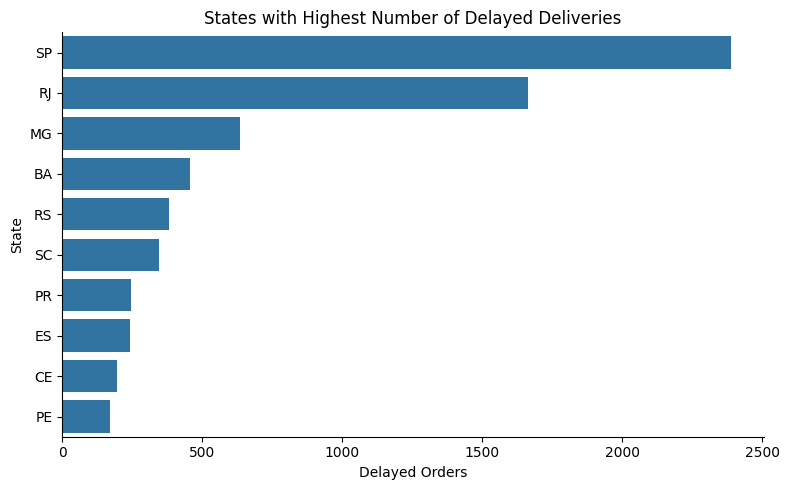

In [72]:
top10 = delay_by_state.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x='delayed_orders',
    y='customer_state'
)

plt.xlabel("Delayed Orders")
plt.ylabel("State")
plt.title("States with Highest Number of Delayed Deliveries")

sns.despine()
plt.tight_layout()
plt.show()

In [73]:
# Delay Rate by State

query = '''
WITH state_orders AS (
    SELECT
        c.customer_state,
        COUNT(DISTINCT o.order_id) AS total_orders
    FROM orders o
    JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY c.customer_state
),

state_delays AS (
    SELECT
        c.customer_state,
        COUNT(DISTINCT o.order_id) AS delayed_orders
    FROM orders o
    JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date > o.order_estimated_delivery_date
    GROUP BY c.customer_state
)

SELECT
    s.customer_state,
    s.total_orders,
    COALESCE(d.delayed_orders, 0) AS delayed_orders,

    ROUND(
        COALESCE(d.delayed_orders, 0) * 100.0 /
        s.total_orders,
        2
    ) AS delay_rate

FROM state_orders s

LEFT JOIN state_delays d
ON s.customer_state = d.customer_state

ORDER BY delay_rate DESC;
'''

state_delay_rate = pd.read_sql(query, conn)

state_delay_rate.head(15)

,customer_state,total_orders,delayed_orders,delay_rate
0,AL,397,95,23.93
1,MA,717,141,19.67
2,PI,476,76,15.97
3,CE,1279,196,15.32
4,SE,335,51,15.22
5,BA,3256,457,14.04
6,RJ,12350,1664,13.47
7,TO,274,35,12.77
8,PA,946,117,12.37
9,ES,1995,244,12.23


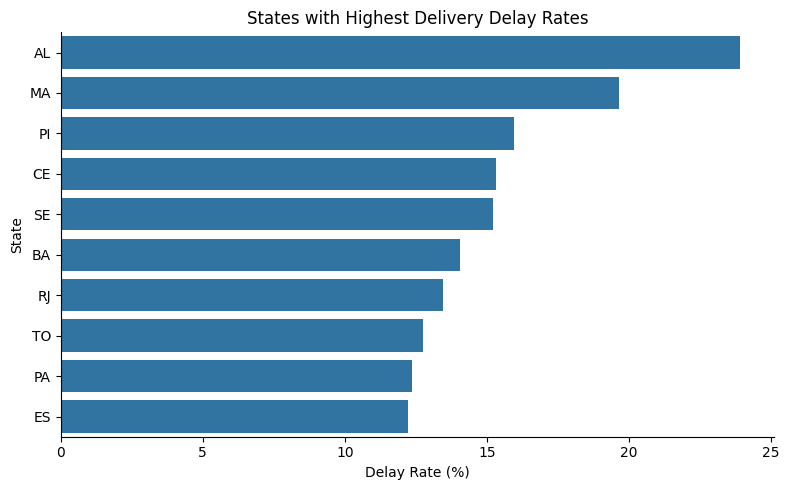

In [74]:
top10 = state_delay_rate.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x='delay_rate',
    y='customer_state'
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("State")
plt.title("States with Highest Delivery Delay Rates")

sns.despine()
plt.tight_layout()
plt.show()

In [75]:
state_delay_rate[state_delay_rate['total_orders'] >= 1000]

,customer_state,total_orders,delayed_orders,delay_rate
3,CE,1279,196,15.32
5,BA,3256,457,14.04
6,RJ,12350,1664,13.47
9,ES,1995,244,12.23
13,PE,1593,172,10.80
15,SC,3546,346,9.76
16,GO,1957,160,8.18
17,RS,5345,382,7.15
18,DF,2080,147,7.07
20,SP,40501,2387,5.89


**Finding**

- Delivery delays are not evenly distributed across customer states.

- Among states with more than 1,000 delivered orders, delay rates range from 5.0% in PR to 15.3% in CE. 

> This indicates that delivery performance varies significantly across regions rather than affecting customers uniformly.

#### 2.6 Delayed Revenue Concentration by State
Which customer states contribute the most delayed-delivery revenue exposure?

In [76]:
# Delayed-delivery revenue by customer state

query = '''
SELECT
    c.customer_state,

    COUNT(DISTINCT o.order_id) AS delayed_orders,

    ROUND(
        SUM(p.payment_value),
        2
    ) AS delayed_revenue

FROM orders o

JOIN customers c
ON o.customer_id = c.customer_id

JOIN payments p
ON o.order_id = p.order_id

WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date > o.order_estimated_delivery_date

GROUP BY c.customer_state

ORDER BY delayed_revenue DESC;
'''

delay_revenue_state = pd.read_sql(query, conn)

delay_revenue_state.head(15)

,customer_state,delayed_orders,delayed_revenue
0,SP,2386,384974.35
1,RJ,1664,279053.59
2,MG,637,107149.35
3,BA,457,85017.44
4,RS,382,62685.04
5,SC,346,52549.27
6,ES,244,43875.13
7,PR,246,42400.86
8,CE,196,39958.82
9,PE,172,35006.34


In [77]:
delay_revenue_state['revenue_share'] = (
    delay_revenue_state['delayed_revenue']
    / delay_revenue_state['delayed_revenue'].sum()
    * 100
).round(2)

delay_revenue_state.head(15)

,customer_state,delayed_orders,delayed_revenue,revenue_share
0,SP,2386,384974.35,28.48
1,RJ,1664,279053.59,20.65
2,MG,637,107149.35,7.93
3,BA,457,85017.44,6.29
4,RS,382,62685.04,4.64
5,SC,346,52549.27,3.89
6,ES,244,43875.13,3.25
7,PR,246,42400.86,3.14
8,CE,196,39958.82,2.96
9,PE,172,35006.34,2.59


In [78]:
delay_revenue_state['cumulative_share'] = (
    delay_revenue_state['revenue_share']
    .cumsum()
    .round(2)
)

delay_revenue_state.head(15)

,customer_state,delayed_orders,delayed_revenue,revenue_share,cumulative_share
0,SP,2386,384974.35,28.48,28.48
1,RJ,1664,279053.59,20.65,49.13
2,MG,637,107149.35,7.93,57.06
3,BA,457,85017.44,6.29,63.35
4,RS,382,62685.04,4.64,67.99
5,SC,346,52549.27,3.89,71.88
6,ES,244,43875.13,3.25,75.13
7,PR,246,42400.86,3.14,78.27
8,CE,196,39958.82,2.96,81.23
9,PE,172,35006.34,2.59,83.82


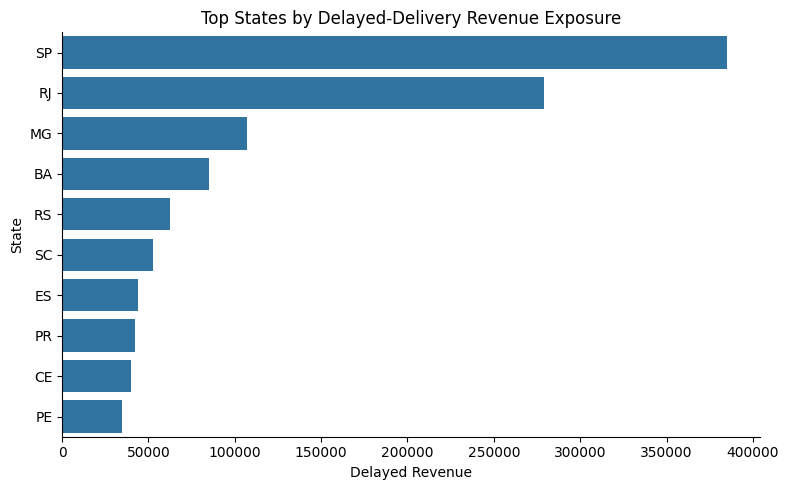

In [79]:
top10 = delay_revenue_state.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top10,
    x='delayed_revenue',
    y='customer_state'
)

plt.xlabel("Delayed Revenue")
plt.ylabel("State")
plt.title("Top States by Delayed-Delivery Revenue Exposure")

sns.despine()
plt.tight_layout()
plt.show()

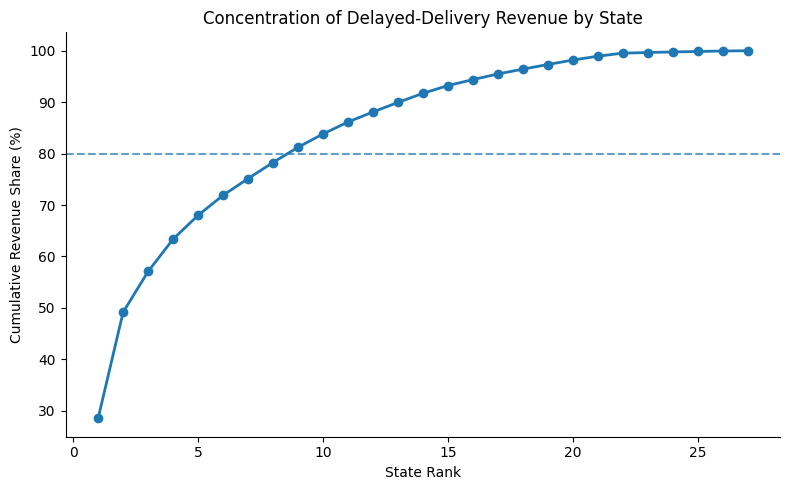

In [80]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(delay_revenue_state)+1),
    delay_revenue_state['cumulative_share'],
    marker='o',
    linewidth=2
)

plt.axhline(y=80, linestyle='--', alpha=0.7)

plt.xlabel("State Rank")
plt.ylabel("Cumulative Revenue Share (%)")
plt.title("Concentration of Delayed-Delivery Revenue by State")

sns.despine()
plt.tight_layout()
plt.show()

In [81]:
# to check internal consistency
delay_revenue_state['delayed_revenue'].sum()

np.float64(1351646.7900000003)

**Insights**

- Delayed-delivery revenue exposure is geographically concentrated.

- Although delayed deliveries occur across the business, nearly half of all delayed-delivery revenue is associated with just two states (`SP and RJ`), while the top 5-states account for approximately `68%` of total exposure.

> This suggests that delivery-related revenue risk is driven more by regional logistics performance than by product category mix.

#### 2.7 Review Score Impact of Delivery Delays

In [82]:
query = '''
SELECT ROUND(AVG(CASE WHEN (o.order_delivered_customer_date > o.order_estimated_delivery_date) THEN r.review_score END), 2) AS avg_late_rating,
       ROUND(AVG(CASE WHEN (o.order_delivered_customer_date <= o.order_estimated_delivery_date) THEN r.review_score END), 2) AS avg_ON_time_rating
FROM reviews r JOIN orders o
ON r.order_id = o.order_id
WHERE o.order_status = "delivered";
''' # AVG() ignores NULL values.
avg_rating = pd.read_sql(query, conn)
avg_rating

,avg_late_rating,avg_ON_time_rating
0,2.57,4.29


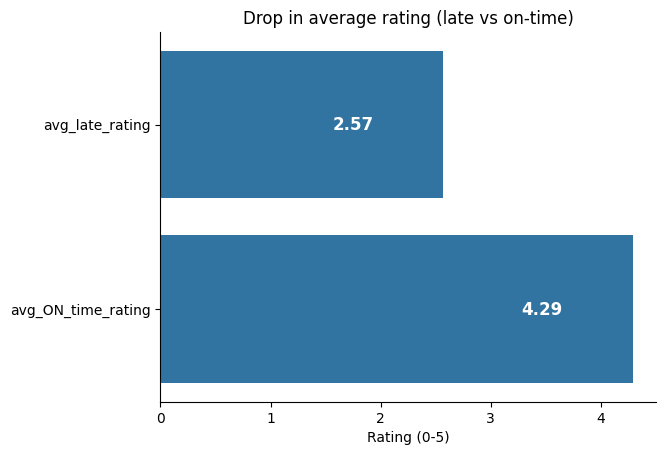

In [83]:
plt.figure()
ax = sns.barplot( x=avg_rating.iloc[0], y=avg_rating.columns, orient='h' )
ax.bar_label(ax.containers[0], padding=-80, color='white', fontsize=12, fontweight='bold')

plt.xlabel('Rating (0-5)')
plt.ylabel('')
plt.title("Drop in average rating (late vs on-time)")
sns.despine()
plt.show()

In [84]:
print("Drop in average rating (late vs on-time):", 
      float((avg_rating['avg_ON_time_rating'][0] / avg_rating['avg_late_rating'][0]).round(2))
)

Drop in average rating (late vs on-time): 1.67


#### 2.8 Experience & Customer return behaviour

In [85]:
query = '''
WITH bad_exp_customers AS (
    SELECT DISTINCT c.customer_unique_id AS id
    FROM customers c 
    JOIN orders o
    ON c.customer_id = o.customer_id
    JOIN reviews r 
    ON r.order_id = o.order_id
    WHERE (o.order_status = "delivered" AND (o.order_delivered_customer_date > o.order_estimated_delivery_date) 
        AND r.review_score <= 2)
), 
customers_order_count AS (
    SELECT b.id, COUNT(o.order_id) AS total_orders
    FROM bad_exp_customers b JOIN customers c
    ON b.id = c.customer_unique_id
    JOIN orders o
    ON o.customer_id = c.customer_id
    GROUP BY b.id
)

SELECT COUNT(*) AS total_customers, 
       SUM(CASE WHEN total_orders = 1 THEN 1 ELSE 0 END) AS one_time, 
       SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) AS repeat
FROM customers_order_count;
'''

repeat_orders = pd.read_sql(query, conn)
repeat_orders

,total_customers,one_time,repeat
0,4121,3933,188


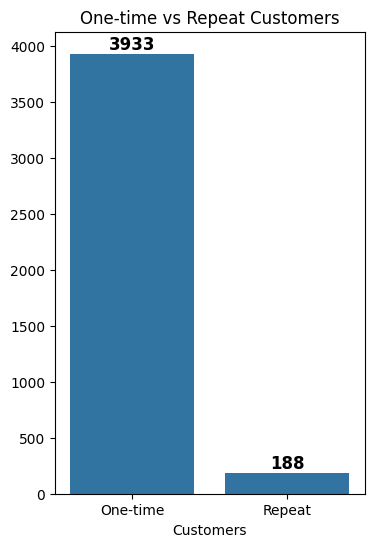

In [86]:
plt.figure(figsize = (4,6))
ax = sns.barplot(y=repeat_orders[['one_time', 'repeat']].iloc[0], x=['One-time', 'Repeat'])

ax.bar_label(ax.containers[0], fontsize=12, fontweight='bold')

plt.xlabel('Customers')
plt.ylabel('')
plt.title('One-time vs Repeat Customers')
plt.show()

In [87]:
print("Repeat rate after late delivery:", 
      float((repeat_orders['repeat'][0] / repeat_orders['total_customers'][0] * 100).round(2)), "%"
)
print("Percentage of customers who never reordered after late delivery:", 
      float((repeat_orders['one_time'][0] / repeat_orders['total_customers'][0] * 100).round(2)), "%"
)

Repeat rate after late delivery: 4.56 %
Percentage of customers who never reordered after late delivery: 95.44 %


#### 2.9 Delay severity analysis
How severe are delivery delays and how does customer satisfaction change?

In [88]:
query = '''
WITH order_revenue AS (
    SELECT
        order_id,
        SUM(payment_value) AS revenue
    FROM payments
    GROUP BY order_id
),

delayed_orders AS (
    SELECT
        o.order_id,

        CAST(
            JULIANDAY(o.order_delivered_customer_date)
            - JULIANDAY(o.order_estimated_delivery_date)
            AS INTEGER
        ) AS delay_days,

        r.review_score,

        p.revenue

    FROM orders o

    JOIN reviews r
    ON o.order_id = r.order_id

    JOIN order_revenue p
    ON o.order_id = p.order_id

    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date > o.order_estimated_delivery_date
),

delay_buckets AS (
    SELECT
        CASE
            WHEN delay_days BETWEEN 1 AND 3 THEN '1-3 Days'
            WHEN delay_days BETWEEN 4 AND 7 THEN '4-7 Days'
            WHEN delay_days BETWEEN 8 AND 14 THEN '8-14 Days'
            ELSE '15+ Days'
        END AS delay_bucket,

        order_id,
        revenue,
        review_score

    FROM delayed_orders
)

SELECT
    delay_bucket,

    COUNT(DISTINCT order_id) AS orders,

    ROUND(SUM(revenue), 2) AS revenue,

    ROUND(AVG(review_score), 2) AS avg_review_score

FROM delay_buckets

GROUP BY delay_bucket

ORDER BY
    CASE
        WHEN delay_bucket = '1-3 Days' THEN 1
        WHEN delay_bucket = '4-7 Days' THEN 2
        WHEN delay_bucket = '8-14 Days' THEN 3
        ELSE 4
    END;
'''

delay_severity = pd.read_sql(query, conn)

delay_severity

,delay_bucket,orders,revenue,avg_review_score
0,1-3 Days,1852,292899.39,3.29
1,4-7 Days,1748,313888.23,2.10
2,8-14 Days,1446,264907.41,1.68
3,15+ Days,2614,446183.48,2.86


In [89]:
delay_severity['orders'].sum()

np.int64(7660)

In [90]:
query = '''
SELECT
    COUNT(*) AS late_orders
FROM orders
WHERE order_status = 'delivered'
AND order_delivered_customer_date > order_estimated_delivery_date;
'''

pd.read_sql(query, conn)

,late_orders
0,7826


In [91]:
query = '''
SELECT
    COUNT(DISTINCT o.order_id) AS late_orders_with_reviews
FROM orders o
JOIN reviews r
ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
AND o.order_delivered_customer_date > o.order_estimated_delivery_date;
'''

pd.read_sql(query, conn)

,late_orders_with_reviews
0,7661


### Findings

- `8.11%` of delivered orders arrived later than the promised delivery date, impacting `8.32%` of customers.
- Delayed deliveries were associated with `₹1.35M` revenue, representing `8.76%` of total revenue.
- Delivery performance varied widely by region, with delay rates reaching `15.3%` in some major states versus `5.0%` in others.
- Just `2` states (`SP` and `RJ`) accounted for nearly `50%` of all delayed-delivery revenue (`₹664K` of `₹1.35M`).
- Average customer ratings dropped from `4.29` to `2.57` when deliveries arrived late.

### Recommendation

- Prioritize logistics improvement efforts in `SP` and `RJ`, where nearly half of delayed-delivery revenue exposure is concentrated.
- Investigate operational drivers behind high-delay states to reduce revenue exposure and improve customer experience.

### 3. Operational Leakage
This section evaluates direct revenue loss from cancelled orders and tests whether cancellation risk is concentrated in specific regions.


In [92]:
query = '''
SELECT
    order_status,
    COUNT(*) AS orders
FROM orders
GROUP BY order_status
ORDER BY orders DESC;
'''

pd.read_sql(query, conn)

,order_status,orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [93]:
query = '''
SELECT
    c.customer_state,
    COUNT(*) AS cancelled_orders
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
WHERE o.order_status = 'canceled'
GROUP BY c.customer_state
ORDER BY cancelled_orders DESC
LIMIT 15;
'''

pd.read_sql(query, conn)

,customer_state,cancelled_orders
0,SP,327
1,RJ,86
2,MG,64
3,RS,25
4,PR,22
5,SC,19
6,BA,16
7,GO,13
8,ES,9
9,DF,7


In [94]:
query = '''
SELECT
    oi.seller_id,
    COUNT(DISTINCT oi.order_id) AS cancelled_orders
FROM orders o
JOIN order_items oi
ON o.order_id = oi.order_id
WHERE o.order_status = 'canceled'
GROUP BY oi.seller_id
ORDER BY cancelled_orders DESC
LIMIT 15;
'''

pd.read_sql(query, conn)

,seller_id,cancelled_orders
0,cc419e0650a3c5ba77189a1882b7556a,9
1,6560211a19b47992c3666cc44a7e94c0,7
2,620c87c171fb2a6dd6e8bb4dec959fc6,6
3,c3867b4666c7d76867627c2f7fb22e21,5
4,a416b6a846a11724393025641d4edd5e,5
5,81783131d2a97c8d44d406a4be81b5d9,5
6,ffff564a4f9085cd26170f4732393726,4
7,dbc22125167c298ef99da25668e1011f,4
8,b2ba3715d723d245138f291a6fe42594,4
9,8444e55c1f13cd5c179851e5ca5ebd00,4


#### 3.1 Direct Revenue Loss from Cancellations

Joining orders with payments duplicates rows because a single order can have multiple payment records. Since cancellation analysis is performed at the order level, the correct approach is to use the orders table directly to avoid inflated counts.

In [95]:
query = '''SELECT SUM(CASE WHEN o.order_status = "canceled" THEN p.payment_value ELSE 0 END) AS canceled_revenue,
                  ROUND(100.0 * SUM(CASE WHEN o.order_status = "canceled" THEN p.payment_value ELSE 0 END) / SUM(p.payment_value), 2) AS canceled_pct
           FROM orders o JOIN payments p
           ON o.order_id = p.order_id;
'''
pd.read_sql(query, conn)

,canceled_revenue,canceled_pct
0,143255.6,0.89


#### 3.2 Cancellation Rate by State
Are cancellations disproportionately occurring in certain states?

In [96]:
query = '''
WITH state_orders AS (
    SELECT
        c.customer_state,
        COUNT(*) AS total_orders
    FROM orders o
    JOIN customers c
    ON o.customer_id = c.customer_id
    GROUP BY c.customer_state
),

state_cancellations AS (
    SELECT
        c.customer_state,
        COUNT(*) AS cancelled_orders
    FROM orders o
    JOIN customers c
    ON o.customer_id = c.customer_id
    WHERE o.order_status = 'canceled'
    GROUP BY c.customer_state
)

SELECT
    s.customer_state,
    s.total_orders,
    COALESCE(c.cancelled_orders,0) AS cancelled_orders,

    ROUND(
        COALESCE(c.cancelled_orders,0) * 100.0
        / s.total_orders,
        2
    ) AS cancellation_rate

FROM state_orders s

LEFT JOIN state_cancellations c
ON s.customer_state = c.customer_state

ORDER BY cancellation_rate DESC;
'''

state_cancel = pd.read_sql(query, conn)

state_cancel.head(15)

,customer_state,total_orders,cancelled_orders,cancellation_rate
0,RR,46,1,2.17
1,RO,253,3,1.19
2,PI,495,4,0.81
3,SP,41746,327,0.78
4,RJ,12852,86,0.67
5,GO,2020,13,0.64
6,MG,11635,64,0.55
7,MA,747,4,0.54
8,CE,1336,7,0.52
9,SC,3637,19,0.52


### Findings

- Order cancellations resulted in approximately `₹0.14M` of direct revenue loss.
- Cancellation rates remained below `1%` across major states and showed limited geographic variation.
- No meaningful concentration pattern was identified, suggesting cancellations are not driven by a specific region.

### Recommendation

Geography does not appear to be a major driver of cancellations. Future analysis should focus on operational and order-level causes behind cancelled orders.

## Conclusion

The analysis identified customer retention and delivery performance as the primary sources of revenue risk.

Revenue growth remains heavily dependent on first-time buyers, while delayed deliveries expose a meaningful share of revenue to customer experience issues and are concentrated within a small number of states.

In contrast, cancellation-related losses are relatively limited and do not appear to be driven by geographic concentration.

Overall, the findings indicate that improving retention and delivery execution offers the greatest opportunity to strengthen revenue stability and support sustainable growth.